In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import warnings
import time
import pandas as pd
import random
import numpy.ma as ma
from tqdm import tqdm
import matplotlib.pyplot as plt
import os

import sys
sys.path.append('../src')
from traffic_sim import *

# Both me and monica load from same file
# Look at ways to fix numerical issues - bound by small epsilon (add to denominator)

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/var/folders/kl/txwf6c7d73v3xczbyqm3trhw0000gn/T/ipykernel_73864/3374314806.py:7: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
def smooth_inflow(inflow, window_size=2):
    # Create averaging kernel
    kernel = np.ones(window_size) / window_size
    
    # Compute asymmetric padding for even window sizes
    pad_left = window_size // 2
    pad_right = window_size - pad_left - 1

    # Pad using boundary values (edge padding)
    if inflow.ndim == 1:
        padded = np.pad(inflow, (pad_left, pad_right), mode='edge')
    else:
        padded = np.pad(inflow, ((pad_left, pad_right), (0, 0)), mode='edge')

    # Convolve along time dimension
    smoothed = np.apply_along_axis(
        lambda m: np.convolve(m, kernel, mode="valid"), axis=0, arr=padded
    )
    return smoothed

## Data and calibration loading

In [3]:
# Define parameters for METANET Model
L = 0.4
time_step = 10/3600
total_time = 1 # in hours
start_time = 0 # in hours
start_time_step = int(start_time / time_step)

In [4]:
# Read in the data
data_path = "/Users/shreyaar/Desktop/PhD/research/MPC/data/i24/i24_11_30" #"OCP_sb5" #'OCP_sb3' #"robust_S10_0001" #'updated_cintra' #'test_sb_nonsparse' #
calibration_id = "calibration_static/fixed_ramping" #"calibration_static/fixed_ramping" #"i24_11_30_calibration_static"
results_path = f"/Users/shreyaar/Desktop/PhD/research/MPC/results/i24/i24_11_30/{calibration_id}/hold_length"

calibration_interval = None # None if static, otherwise, parameter interval for dynamic calibration (in time steps)
cal_path = f'{data_path}/{calibration_id}' if calibration_interval is None else f'{data_path}/{calibration_id}/control_h_{calibration_interval}'
if calibration_interval is not None:
    results_path += f"/control_h_{calibration_interval}"


# Assert data exists
assert os.path.exists(cal_path), f"Calibration parameters not found at {cal_path}"
assert os.path.exists(f'{data_path}/v_hat.npy') and os.path.exists(f'{data_path}/rho_hat.npy'), f"Data not found at {data_path}"


In [5]:
density_data = np.load(f'{data_path}/rho_hat.npy')
# velocity_data = np.load(f'{data_path}/v_hat.npy')
flow_data = np.load(f'{data_path}/q_hat.npy')
density_data = np.where(density_data == 0.0, 1e-3, density_data)
flow_data = np.where(flow_data == 0.0, 1e-3, flow_data)
velocity_data = flow_data/density_data
# density_data = np.load(f'i35w_data/i35_southbound/i35_sb5_density_{int(time_step * 3600)}sec_{int(L * 1000)}m.npy')
# velocity_data = np.load(f'i35w_data/i35_southbound/i35_sb5_velocity_{int(time_step * 3600)}sec_{int(L * 1000)}m.npy')
print("Time steps, num segments (including boundary cond.):", density_data.shape)

true_density_initial = density_data[start_time_step, 1:-1].reshape(-1)
true_velocity_initial = velocity_data[start_time_step, 1:-1].reshape(-1)

downstream_density = density_data[0:, -1].reshape(-1)
data_inflow = (velocity_data[0:, 0] * density_data[0:, 0]).reshape(-1)
data_inflow = smooth_inflow(data_inflow, window_size=2)
downstream_density = smooth_inflow(downstream_density, window_size=2)

print("time steps:", downstream_density.shape)
print("num segments:", true_density_initial.shape)

Time steps, num segments (including boundary cond.): (360, 16)
time steps: (360,)
num segments: (14,)


In [6]:
time_steps = downstream_density.shape[0]
num_segments = density_data.shape[1] - 2  # Subtract 2 for the boundary segments
total_distance = L * num_segments # km
print("sim_time:", time_step * downstream_density.shape[0] * 60, "minutes")
print("length of highway:", total_distance, "km")

lane_counts = np.load(f'{cal_path}/num_lanes.npy').reshape(-1) if calibration_interval is None else np.load(f'{cal_path}/params_1/num_lanes.npy').reshape(-1)
lane_dict = {i: lane_counts[i] for i in range(num_segments)}

velocity_data = velocity_data[:, 1:-1] # remove boundary conditions for plotting
flow_data = flow_data[:, 1:-1] # remove boundary conditions for plotting
density_data = density_data[:, 1:-1] # remove boundary conditions for plotting

# Normalize densities by lane counts to get per-lane densities
downstream_density = downstream_density / lane_dict[num_segments - 1]
true_density_initial = true_density_initial / lane_counts
density_data = density_data / lane_counts


sim_time: 60.0 minutes
length of highway: 5.6000000000000005 km


In [7]:
print(np.min(density_data))

3.7299995000000004


In [8]:
from param_loader import METANET_Params
import os

subfolders = [
    f for f in os.listdir(cal_path)
    if os.path.isdir(os.path.join(cal_path, f)) and f.startswith("params_")
]

if subfolders:
    print(f"Dynamic parameters detected: {len(subfolders)} subfolder(s) found")
    control_h = time_steps // len(subfolders)
    model_params = METANET_Params(path=f"{data_path}/{calibration_id}", control_h=control_h, num_timesteps=time_steps, num_segments=num_segments).get_params()
else:
    print("No dynamic parameter subfolders found — using static calibration parameters")
    model_params = METANET_Params(path=cal_path, num_timesteps=time_steps, num_segments=num_segments).get_params()

No dynamic parameter subfolders found — using static calibration parameters


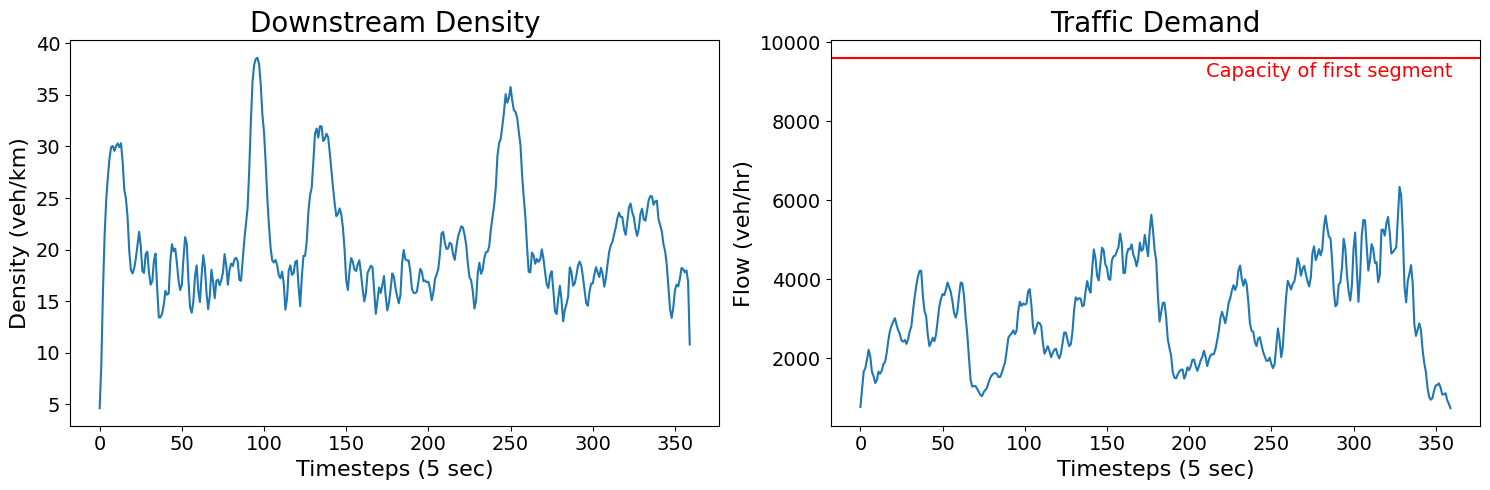

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].plot(downstream_density)
axs[0].set_title('Downstream Density', fontsize=20)
# axs[0].set_xticks(np.arange(0, time_steps+1, 120), np.arange(0, int(time_steps/12)+1, int(120/12)))
axs[0].set_xlabel('Timesteps (5 sec)', fontsize=16)
axs[0].set_ylabel('Density (veh/km)', fontsize=16)

axs[1].plot(data_inflow)
axs[1].set_title('Traffic Demand', fontsize=20)
axs[1].axhline(2400 * lane_counts[0], c='red')
axs[1].text(x=len(data_inflow), y=2400 * lane_counts[0]-100, s="Capacity of first segment", va="top", ha="right", fontsize=14, color="red")
# axs[1].set_xticks(np.arange(0, time_steps+1, 120), np.arange(0, int(time_steps/12)+1, int(120/12)))
axs[1].set_xlabel('Timesteps (5 sec)', fontsize=16)
axs[1].set_ylabel('Flow (veh/hr)', fontsize=16)

for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout()
plt.show()

## Simulation of no control scenario

In [10]:
const_vsl = np.array([np.full(num_segments, np.max(model_params['v_free'])) for i in range(time_steps)])

init_state = (true_density_initial,
              true_velocity_initial,
              data_inflow[start_time_step],
              0)
p_sim, v_sim, queue, tts_sim = run_metanet_sim(time_step,
                                   L, 
                                   init_state, 
                                   data_inflow[start_time_step:],
                                   downstream_density[start_time_step:],
                                   model_params,
                                   lanes = lane_dict,
                                   vsl_speeds=None,
                                   plotting=True,
                                   real_data=True
                                   )

p_sim = p_sim[0:-1, :]
v_sim = v_sim[0:-1, :]

print("Total travel time:", tts_sim, " vehicle-hours")

Total travel time: 550.6291368412816  vehicle-hours


102.54945910649667


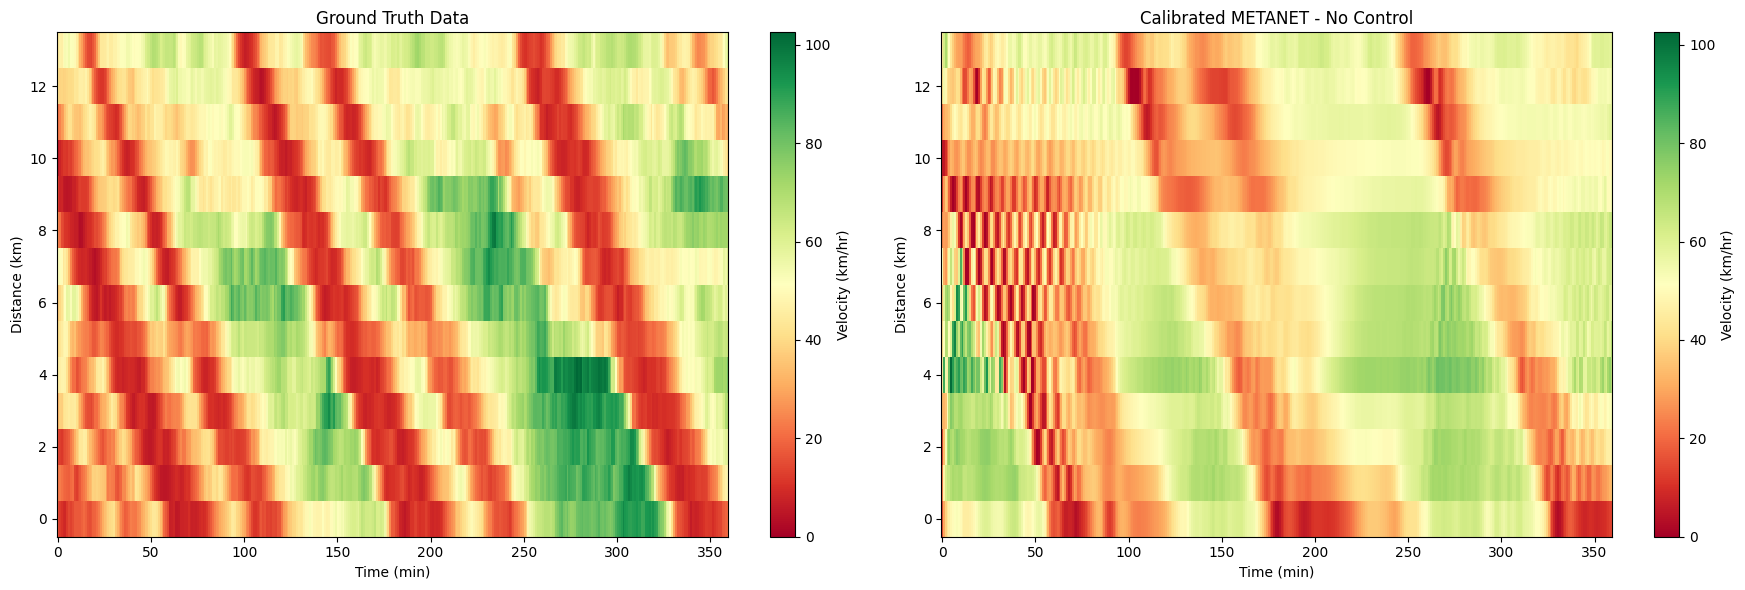

In [11]:
# Read in v_pred.npy from the path location
max_v = max(np.max(velocity_data), np.max(v_sim))
print(max_v)
plt.figure(figsize=(18, 6))

# Plot current v heatmap
plt.subplot(1, 2, 1)
plt.imshow(velocity_data.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=0, vmax=max_v)
plt.xlabel('Time (min)')
plt.ylabel('Distance (km)')
plt.colorbar(label='Velocity (km/hr)')
plt.gca().invert_yaxis()
plt.gca().xaxis.set_ticks_position('bottom')
plt.title('Ground Truth Data')

# Plot v_pred heatmap
plt.subplot(1, 2, 2)
plt.imshow(v_sim.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=0, vmax=max_v)
plt.xlabel('Time (min)')
plt.ylabel('Distance (km)')
plt.colorbar(label='Velocity (km/hr)')
plt.gca().invert_yaxis()
plt.gca().xaxis.set_ticks_position('bottom')
plt.title('Calibrated METANET - No Control')

plt.tight_layout()
plt.show()

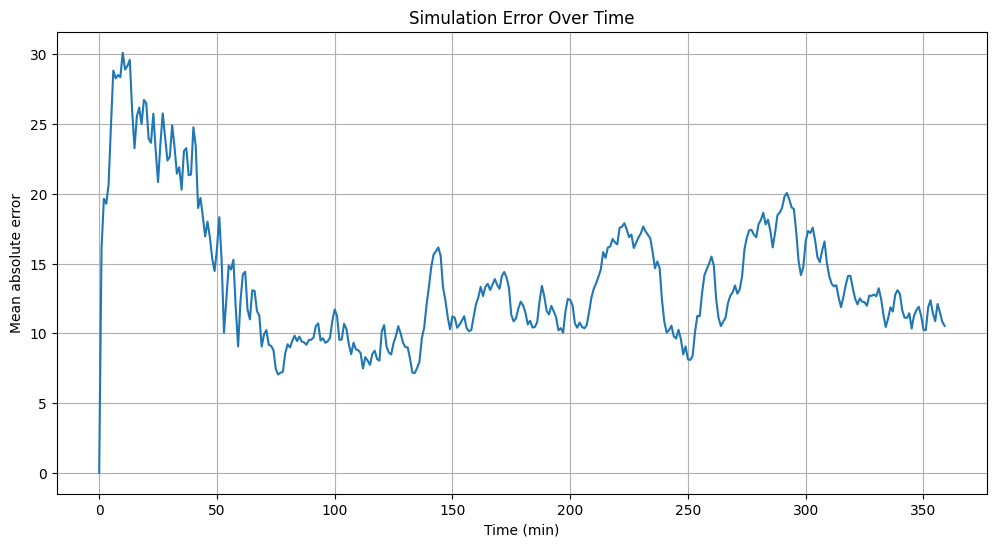

In [12]:
# plot error over time between prediction and simulation
plt.figure(figsize=(12, 6))
plt.plot(np.abs(velocity_data - v_sim).mean(axis=1))
plt.xlabel('Time (min)')
plt.ylabel('Mean absolute error')
plt.title('Simulation Error Over Time')
plt.grid()
plt.show()

In [13]:
flow_sim = v_sim * p_sim * lane_counts

mape = np.mean(np.abs((velocity_data - v_sim) / velocity_data) * 100)
p_mape = np.mean(np.abs((density_data - p_sim) / density_data) * 100)
q_mape = np.mean(np.abs((flow_data - flow_sim) / flow_data) * 100)
print("Density MAPE:", np.round(p_mape, 2), "%")
print("Velocity MAPE:", np.round(mape, 2), "%")
print("Flow MAPE:", np.round(q_mape, 2), "%")

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

rmse_value = rmse(v_sim, velocity_data)
p_rmse_value = rmse(density_data, p_sim)
q_rmse = rmse(flow_data, flow_sim)
print("Density RMSE:", np.round(p_rmse_value, 2))
print("Velocity RMSE:", rmse_value)
print("Flow RMSE:", np.round(q_rmse, 2))

Density MAPE: 33.85 %
Velocity MAPE: 58.06 %
Flow MAPE: 52.89 %
Density RMSE: 9.1
Velocity RMSE: 17.68266329991305
Flow RMSE: 1751.24


In [14]:
# Travel time of gt
gt_tt = time_step * (sum([np.sum(density_data[:, i]) * lane_counts[i] * L for i in range(num_segments)]))
metanet_tt = time_step * (sum([np.sum(p_sim[:, i]) * lane_counts[i] * L for i in range(num_segments)]))
print("Ground Truth Travel Time:", np.round(gt_tt, 2), "veh-hr")
print("Metanet Travel Time:", np.round(metanet_tt, 2), "veh-hr")

print("MAPE on total travel time:", np.abs(gt_tt - metanet_tt) / gt_tt * 100, "%")

Ground Truth Travel Time: 562.15 veh-hr
Metanet Travel Time: 549.26 veh-hr
MAPE on total travel time: 2.2933706625185057 %


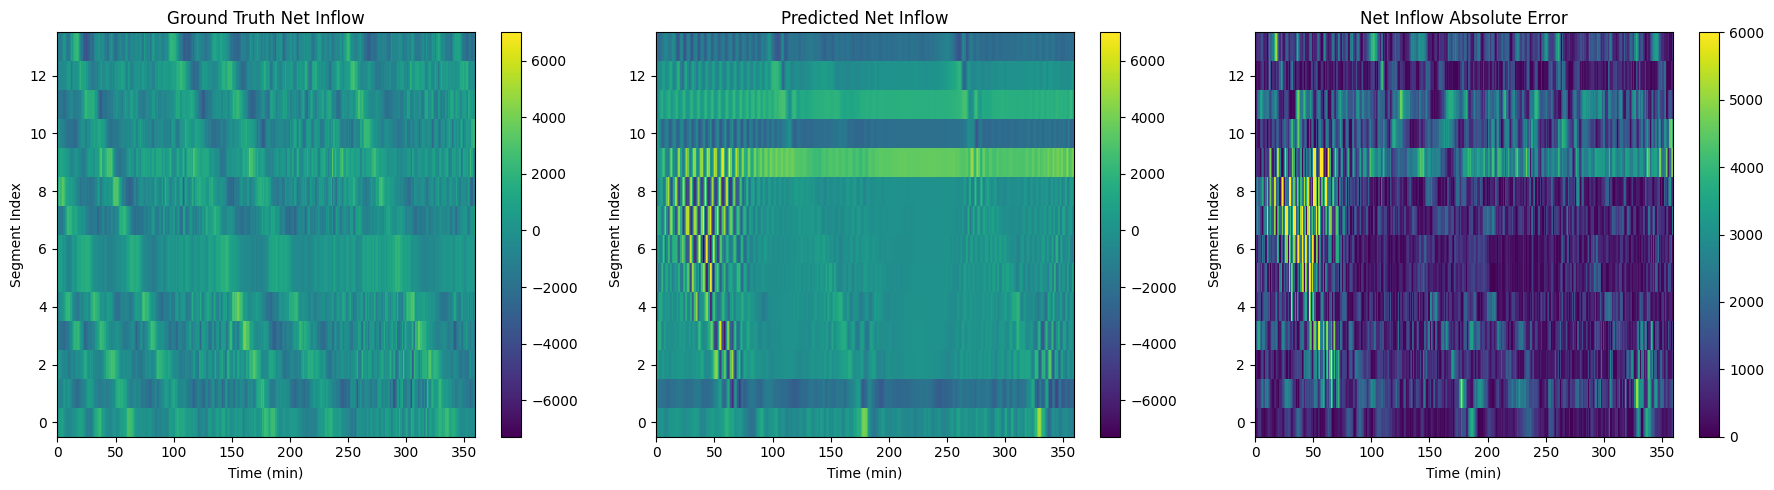

In [15]:
def get_velocity_heatmap(v_hat, v_pred, q_hat, q_pred, rho_hat, rho_pred):
    shortened_v_hat = v_hat
    shortened_rho_hat = rho_hat
    shortened_q_hat = q_hat
    # Determine some set of 3 scalars for each of q, rho, v to make a unified map
    v_diff = np.abs(shortened_v_hat - v_pred)/shortened_v_hat
    rho_diff = np.abs(shortened_rho_hat - rho_pred)/shortened_rho_hat 
    q_diff = np.abs(shortened_q_hat - q_pred)/shortened_q_hat

    diff = v_diff + rho_diff
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

    im = ax1.imshow(diff.T, aspect='auto', origin='lower',
                cmap='viridis', interpolation="none", vmin=0, vmax=1)
    ax1.set_xlabel('Time Step')
    ax1.set_ylabel('Segment Index')
    ax1.set_title('Combined Normalized Difference Heatmap')
    fig.colorbar(im, ax=ax1)

    im2 = ax2.imshow(shortened_v_hat.T, aspect='auto', origin='lower',
                    cmap='RdYlGn', interpolation="none")
    ax2.set_xlabel('Time Step')
    ax2.set_ylabel('Segment Index')
    ax2.set_title('Ground Truth Velocity Heatmap')
    fig.colorbar(im2, ax=ax2, label='Velocity (km/hr)')

    plt.tight_layout()
    plt.show()

# Calculate the error on the net_inflow
def get_net_inflow_error(q_hat, q_pred, highway_inflow):
    # Calculate net inflow for each segment and time
    q_hat_inflow = np.hstack((highway_inflow.reshape(-1, 1), q_hat))[:, :-1]
    q_pred_inflow = np.hstack((highway_inflow.reshape(-1, 1), q_pred))[:, :-1]
    net_inflow_hat = q_hat_inflow - q_hat
    net_inflow_pred = q_pred_inflow - q_pred
    mape = np.abs(net_inflow_hat - net_inflow_pred)

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    netinflow_min = min(net_inflow_hat.min(), net_inflow_pred.min())
    netinflow_max = max(net_inflow_hat.max(), net_inflow_pred.max())

    im0 = axs[0].imshow(net_inflow_hat.T, cmap='viridis', aspect='auto', interpolation='none', vmin=netinflow_min, vmax=netinflow_max)
    axs[0].set_title('Ground Truth Net Inflow')
    axs[0].set_xlabel('Time (min)')
    axs[0].set_ylabel('Segment Index')
    plt.colorbar(im0, ax=axs[0])

    im1 = axs[1].imshow(net_inflow_pred.T, cmap='viridis', aspect='auto', interpolation='none', vmin=netinflow_min, vmax=netinflow_max)
    axs[1].set_title('Predicted Net Inflow')
    axs[1].set_xlabel('Time (min)')
    axs[1].set_ylabel('Segment Index')
    plt.colorbar(im1, ax=axs[1])

    im2 = axs[2].imshow(mape.T, cmap='viridis', aspect='auto', interpolation='none', vmax=6000)
    axs[2].set_title('Net Inflow Absolute Error')
    axs[2].set_xlabel('Time (min)')
    axs[2].set_ylabel('Segment Index')
    plt.colorbar(im2, ax=axs[2])

    for ax in axs:
        ax.invert_yaxis()
        ax.xaxis.set_ticks_position('bottom')

    plt.tight_layout()
    plt.show()


# get_velocity_heatmap(gt, vel, gt * gt_density, flow, gt_density, density)

get_net_inflow_error(flow_data, flow_sim, data_inflow)

TTS (VSL=130): 550.6291368412816
TTS (VSL=150): 550.6291368412816


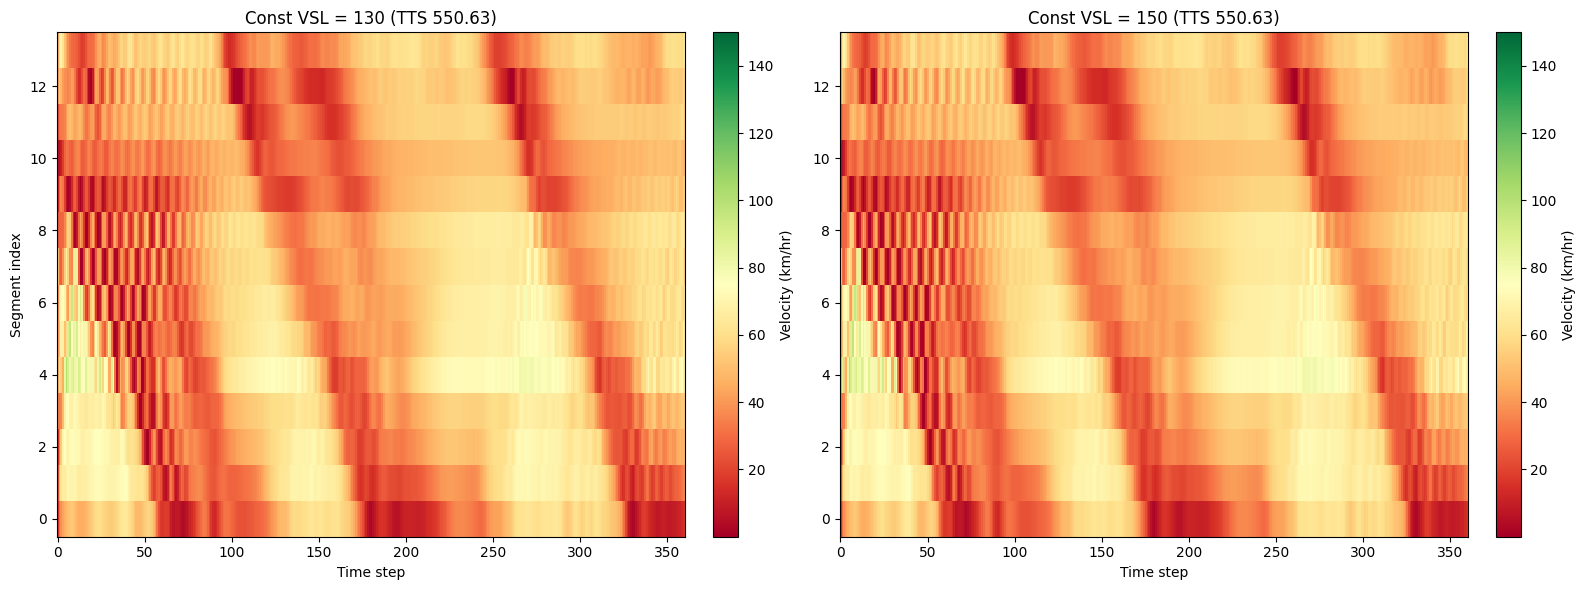

In [16]:
# simulate with constant VSL = 130 and VSL = 150, then plot side-by-side heatmaps
vsl_130 = np.ones((downstream_density.shape[0], num_segments)) * 130
vsl_150 = np.ones((downstream_density.shape[0], num_segments)) * 150

# Run simulations (turn off internal plotting to avoid duplicates)
p_130, v_130, queue_130, tts_130 = run_metanet_sim(time_step, L, init_state,
                                                   data_inflow[start_time:],
                                                   downstream_density[start_time:],
                                                   model_params,
                                                   lanes=lane_dict,
                                                   vsl_speeds=vsl_130,
                                                   plotting=True,
                                                   real_data=False)

p_150, v_150, queue_150, tts_150 = run_metanet_sim(time_step, L, init_state,
                                                   data_inflow[start_time:],
                                                   downstream_density[start_time:],
                                                   model_params,
                                                   lanes=lane_dict,
                                                   vsl_speeds=vsl_150,
                                                   plotting=True,
                                                   real_data=False)

print("TTS (VSL=130):", tts_130)
print("TTS (VSL=150):", tts_150)

# consistent color scale
vmin = min(np.min(velocity_data[:, 1:-1]), v_130.min(), v_150.min())
vmax = 150 #max(np.max(velocity_data[:, 1:-1]), v_130.max(), v_150.max())

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

im0 = axs[0].imshow(v_130.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=vmin, vmax=vmax)
axs[0].set_title(f'Const VSL = 130 (TTS {np.round(tts_130,2)})')
axs[0].set_xlabel('Time step')
axs[0].set_ylabel('Segment index')
axs[0].invert_yaxis()
axs[0].xaxis.set_ticks_position('bottom')
cbar0 = fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)
cbar0.set_label('Velocity (km/hr)')

im1 = axs[1].imshow(v_150.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=vmin, vmax=vmax)
axs[1].set_title(f'Const VSL = 150 (TTS {np.round(tts_150,2)})')
axs[1].set_xlabel('Time step')
axs[1].invert_yaxis()
axs[1].xaxis.set_ticks_position('bottom')
cbar1 = fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)
cbar1.set_label('Velocity (km/hr)')

plt.tight_layout()
plt.show()


## Optimize speed limits for controllable congestion

In [30]:
pred_horizon = 40  # in time steps
control_horizon = 5 # in time steps
hold_len = 1

opt_horizon = time_steps + pred_horizon - control_horizon
downstream_density_mpc = np.append(downstream_density, downstream_density[-1])
inflow_mpc = np.append(data_inflow, data_inflow[-1])
while len(downstream_density_mpc) <= opt_horizon + 1:
    downstream_density_mpc = np.append(downstream_density_mpc, downstream_density[-1])
    inflow_mpc = np.append(inflow_mpc, data_inflow[-1])

print(data_inflow.shape, downstream_density.shape)
print(downstream_density_mpc.shape, inflow_mpc.shape, time_steps)

(360,) (360,)
(397,) (397,) 360


In [31]:
init_state = (true_density_initial,
              true_velocity_initial,
              data_inflow[start_time],
              0)

In [32]:
for k, v in model_params.items():
    if isinstance(v, np.ndarray) and v.ndim == 2:
        print(k, v.shape, "sliced!" if v.shape[0] == time_steps else "NOT SLICED — passed through whole")

In [69]:
# Optimize I-24 Scenario
import json
from mpc_metanet import mpc_find_vsl

# init_vsl = np.load(f'{results_path}/optimal_vsl_90.npy')
for hold_len in [5]:
    vsl_opt_config = {
        "hold_length": hold_len,
        "control_changepoints": None,
        "safety_temporal": None,
        "safety_spatial": None,
        "speed_lb": 0,
        "warmup_time": 0, 
        "control_zone": [i for i in range(2, num_segments)],
        "control_one_segment": None,
        "initialize_vsl": None,
        "init_fixed": 150, #speed if speed > 0 else None,
        "tee": True,
        "pred_horizon": 40,
        "control_horizon": 10
    }

    opt_horizon = time_steps + vsl_opt_config["pred_horizon"] - vsl_opt_config["control_horizon"]

    print(f"Starting optimization... ")
    optimal_vsl = mpc_find_vsl(opt_horizon, inflow_mpc[start_time:], downstream_density_mpc[start_time:], lane_dict,
                            T=time_step,l=L, num_segments=num_segments, init_state=init_state, params=model_params, verbose=True, v_fd_penalty=1e14, **vsl_opt_config)

    print(optimal_vsl.shape)

    path_id = f"optimal_vsl_{hold_len}"
    os.makedirs(results_path, exist_ok=True)
    np.save(f'{results_path}/{path_id}.npy', optimal_vsl)
    with open(f'{results_path}/{path_id}_config.json', "w") as file:
        json.dump(vsl_opt_config, file, indent=4)

Starting optimization... 
[MPC] t = 0
Ipopt 3.14.16: constr_viol_tol=0.001
acceptable_constr_viol_tol=0.01
tol=0.0001
acceptable_tol=0.01
acceptable_dual_inf_tol=0.01
acceptable_iter=5
warm_start_init_point=yes
output_file=/var/folders/kl/txwf6c7d73v3xczbyqm3trhw0000gn/T/tmpgs4gtmq_ipopt_out
max_iter=1000000
max_cpu_time=1e+20


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.16, running with linear solver MUMPS 5.6.2.

Number of nonzeros in equality constraint Jacobian...:     8182
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:     3721

Total number of va

  - termination condition: infeasible
  - message from solver: Ipopt 3.14.16\x3a Converged to a locally infeasible point. Problem may be infeasible.
INFO:pyomo.util.infeasible:CONSTR constraints[297]: 0.13636332880783053 =/= 0.0
  - EXPR: density[4,9] - (density[3,9] + 0.001736111111111111*(density[3,8]*velocity[3,8]*4.860748562409972 + 0.001 - density[3,9]*velocity[3,9]*4.0/0.4000000000072068)) =/= 0.0
  - VAR density[4,9]: 3.548907165331859
  - VAR density[3,9]: 3.875856608979702
  - VAR density[3,8]: 6.988501954547978
  - VAR velocity[3,8]: 28.964607430028053
  - VAR velocity[3,9]: 32.271009858133795


[MPC t=0] Solver failed: Solver found problem infeasible.
  downstream_density=[ 4.60749956  8.75999947 15.93374944 21.33999925 24.847499   27.01749869
 28.87499847 29.95124859 30.04249897 29.56874903 30.06124894 30.29499913
 29.93499919 30.31749912 28.48624888 25.80374913 24.92874931 23.10624909
 19.86124909 18.04624897 17.67999891 18.181249   19.12124884 20.42874872
 21.724999   20.34374913 17.89749884 17.73624875 19.57749881 19.79874888
 17.77499894 16.59999925 16.912499   18.89624881 19.61249912 16.18999928
 13.41624928 13.432499   13.76999922 14.64499928 15.99624903]
  traffic_demand=[ 762.7968  1217.01645 1659.39705 1744.1388  1959.16545 2211.2658
 2043.3321  1652.36355 1540.8531  1368.9288  1442.3481  1658.232
 1602.765   1683.6183  1846.5606  1901.17395 2132.43705 2449.78515
 2699.6058  2826.5742  2923.4691  3011.4549  2839.7439  2700.95085
 2610.38115 2443.5486  2415.4065  2457.91125 2359.02735 2477.952
 2673.9225  2805.64335 3196.24875 3541.39065 3835.04535 4063.25565
 4207.3

  - termination condition: infeasible
  - message from solver: Ipopt 3.14.16\x3a Converged to a locally infeasible point. Problem may be infeasible.
INFO:pyomo.util.infeasible:CONSTR constraints[143]: 7.763986388908961e-06 =/= 0.0
  - EXPR: v_fd[0,4] - 0.5*(94.17244619395643*exp(-0.20000000000065413*(0.05213812904178745*density[0,4])**4.999999999983647) + vsl[0,4] - sqrt((94.17244619395643*exp(-0.20000000000065413*(0.05213812904178745*density[0,4])**4.999999999983647) - vsl[0,4])**2 + 0.5)) =/= 0.0
  - VAR v_fd[0,4]: 94.12883665144975
  - VAR density[0,4]: 5.625999600070672
  - VAR vsl[0,4]: 139.99029561417774
INFO:pyomo.util.infeasible:CONSTR constraints[146]: 1.3990103866490244e-06 =/= 0.0
  - EXPR: v_fd[0,5] - 0.5*(70.00000000052538*exp(-0.20000000000232265*(0.05109289561934669*density[0,5])**4.999999999941934) + vsl[0,5] - sqrt((70.00000000052538*exp(-0.20000000000232265*(0.05109289561934669*density[0,5])**4.999999999941934) - vsl[0,5])**2 + 0.5)) =/= 0.0
  - VAR v_fd[0,5]: 69.9598

ValueError: Solver found problem infeasible.
  downstream_density=[ 4.60749956  8.75999947 15.93374944 21.33999925 24.847499   27.01749869
 28.87499847 29.95124859 30.04249897 29.56874903 30.06124894 30.29499913
 29.93499919 30.31749912 28.48624888 25.80374913 24.92874931 23.10624909
 19.86124909 18.04624897 17.67999891 18.181249   19.12124884 20.42874872
 21.724999   20.34374913 17.89749884 17.73624875 19.57749881 19.79874888
 17.77499894 16.59999925 16.912499   18.89624881 19.61249912 16.18999928
 13.41624928 13.432499   13.76999922 14.64499928 15.99624903]
  traffic_demand=[ 762.7968  1217.01645 1659.39705 1744.1388  1959.16545 2211.2658
 2043.3321  1652.36355 1540.8531  1368.9288  1442.3481  1658.232
 1602.765   1683.6183  1846.5606  1901.17395 2132.43705 2449.78515
 2699.6058  2826.5742  2923.4691  3011.4549  2839.7439  2700.95085
 2610.38115 2443.5486  2415.4065  2457.91125 2359.02735 2477.952
 2673.9225  2805.64335 3196.24875 3541.39065 3835.04535 4063.25565
 4207.3173  4211.419

In [ ]:
density, velocity, flow_or, queue = run_metanet_sim(
    time_step, L, init_state, data_inflow[50:50+pred_horizon+1],
    downstream_density[50:50+pred_horizon],
    params_mpc, vsl_speeds=np.full((pred_horizon, num_segments), 90.0),
    lanes=lanes, real_data=False
)
print(velocity.min(), density.min())

NameError: name 'T' is not defined

In [1112]:
# # Print ramp info
# print("Ramp info:")
# for i in range(num_segments):
#     print(f"Segment {i}: lanes={lane_dict[i]}, on-ramp={model_params['r'][i] > 0.001}, off-ramp={model_params['beta'][i] > 0.001}")

## Plotting controlled traffic scenario

In [ ]:
np.set_printoptions(suppress=True)

vsl_test = np.ones((opt_horizon, num_segments)) * 150
p_baseline, v_baseline, _, tts_baseline = run_metanet_sim(time_step,
                                   L, 
                                   init_state, 
                                   data_inflow,
                                   downstream_density,
                                   model_params,
                                   lanes = lane_dict,
                                   vsl_speeds=vsl_test,
                                   plotting=True,
                                   real_data=False
)

print(tts_baseline)

plt.imshow(v_baseline.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=0, vmax=np.max(velocity_data))
plt.title('Simulation with Optimal VSL from MPC')
plt.xlabel('Time (min)')
plt.ylabel('Distance (km)')
plt.colorbar(label='Velocity (km/hr)')
plt.gca().invert_yaxis()
plt.gca().xaxis.set_ticks_position('bottom')
plt.show()

ValueError: operands could not be broadcast together with shapes (360,14) (390,14) 

In [68]:
print(np.min(v_baseline), np.max(v_baseline))
print(np.min(p_baseline), np.max(p_baseline))
print(model_params['v_free'].max())

0.0010000000847298907 101.27808309169065
3.4125046780403556 76.40462127274179
149.99999998193658


383.57172585432437


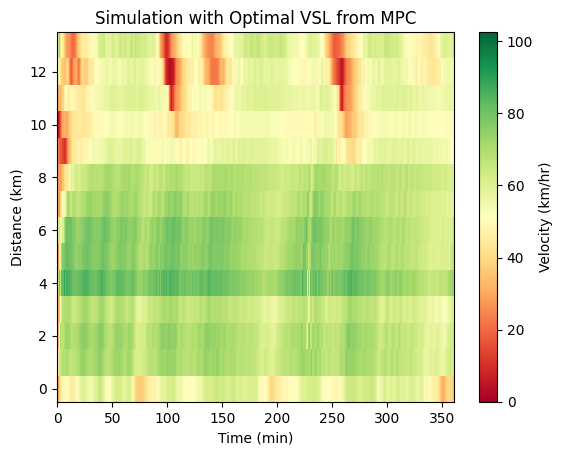

In [44]:
optimal_vsl = np.load(f'{results_path}/optimal_vsl_1.npy')
p_opt, v_opt, queue, tts_opt = run_metanet_sim(time_step,
                                   L, 
                                   init_state, 
                                   data_inflow,
                                   downstream_density,
                                   model_params,
                                   lanes=lane_dict,
                                   vsl_speeds=optimal_vsl,
                                   plotting=True,
                                   real_data=False
)

print(tts_opt)

plt.imshow(v_opt.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=0, vmax=np.max(velocity_data))
plt.title('Simulation with Optimal VSL from MPC')
plt.xlabel('Time (min)')
plt.ylabel('Distance (km)')
plt.colorbar(label='Velocity (km/hr)')
plt.gca().invert_yaxis()
plt.gca().xaxis.set_ticks_position('bottom')
plt.show()

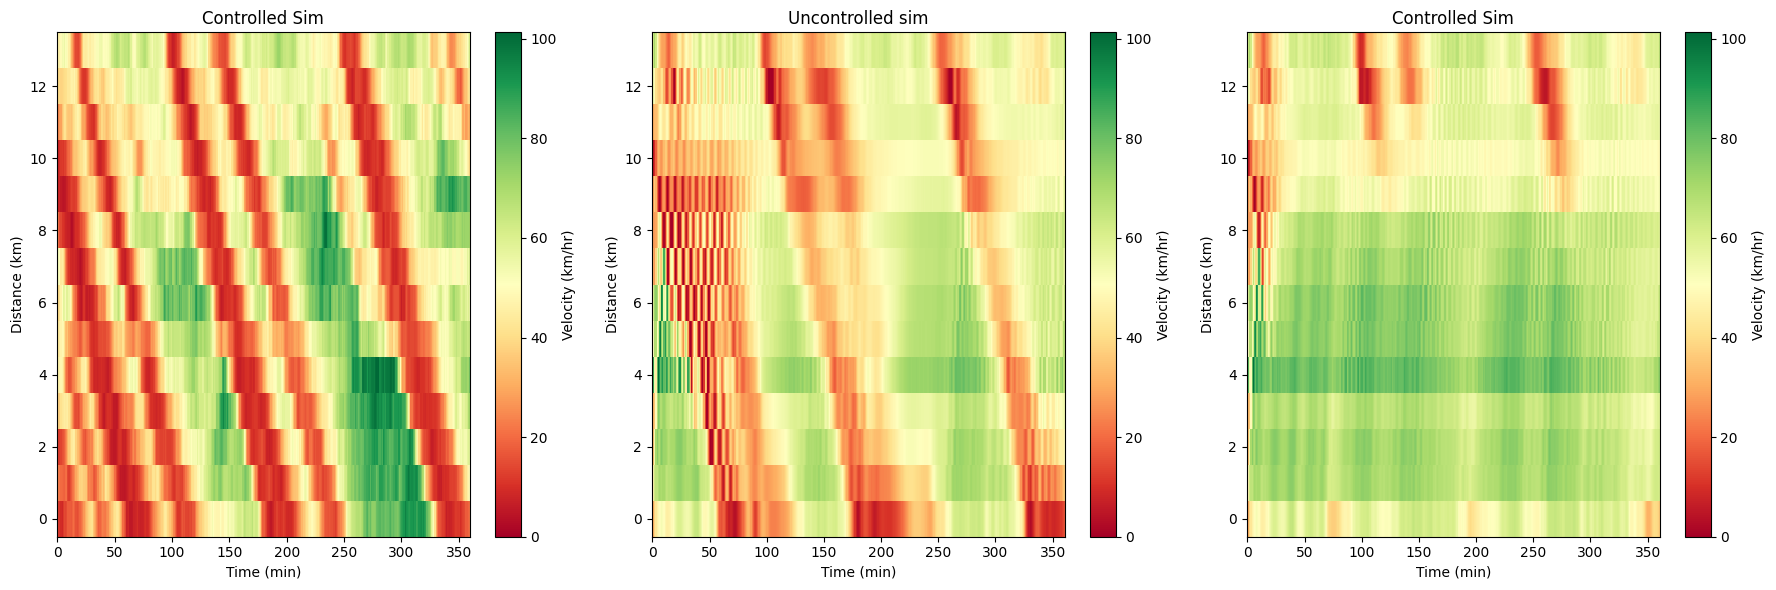

In [1277]:
# Read in v_pred.npy from the path location
max_v = max(np.max(v_baseline), np.max(v_opt))
plt.figure(figsize=(18, 6))

# Plot current v heatmap

plt.subplot(1, 3, 1)
plt.imshow(velocity_data.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=0, vmax=max_v)
plt.xlabel('Time (min)')
plt.ylabel('Distance (km)')
plt.colorbar(label='Velocity (km/hr)')
plt.gca().invert_yaxis()
plt.gca().xaxis.set_ticks_position('bottom')
plt.title('Controlled Sim')

plt.subplot(1, 3, 2)
plt.imshow(v_baseline.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=0, vmax=max_v)
plt.xlabel('Time (min)')
plt.ylabel('Distance (km)')
plt.colorbar(label='Velocity (km/hr)')
plt.gca().invert_yaxis()
plt.gca().xaxis.set_ticks_position('bottom')
plt.title('Uncontrolled sim')

# Plot v_pred heatmap
plt.subplot(1, 3, 3)
plt.imshow(v_opt.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=0, vmax=max_v)
plt.xlabel('Time (min)')
plt.ylabel('Distance (km)')
plt.colorbar(label='Velocity (km/hr)')
plt.gca().invert_yaxis()
plt.gca().xaxis.set_ticks_position('bottom')
plt.title('Controlled Sim')

plt.tight_layout()
plt.savefig("/Users/shreyaar/Desktop/PhD/research/MPC/figs/11_22_tsdiagram", dpi=150, bbox_inches='tight')
plt.show()

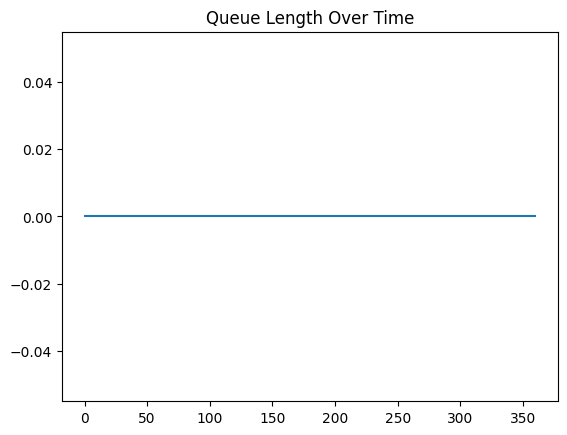

In [1278]:
plt.plot(queue)
plt.title('Queue Length Over Time')
plt.show()

In [1279]:
print(f"TTS with VSL Control: {tts_opt} veh-hrs")
print(f"TTS with No Control: {tts_baseline} veh-hrs")

TTS with VSL Control: 392.6207959239153 veh-hrs
TTS with No Control: 550.6291368412816 veh-hrs


In [1240]:
from generate_demand_synthetic import get_ff_tts

ff_ttt = get_ff_tts(data_inflow, time_step, L, np.max(model_params['v_free'], axis=0))
print("Total free flow travel time:", ff_ttt, "veh-hrs")
delay  = tts_baseline - ff_ttt
opt_delay = tts_opt - ff_ttt
cc = (delay - opt_delay) / delay * 100
print(f"Controllable congestion: {cc}%")

TypeError: 'numpy.float64' object is not iterable

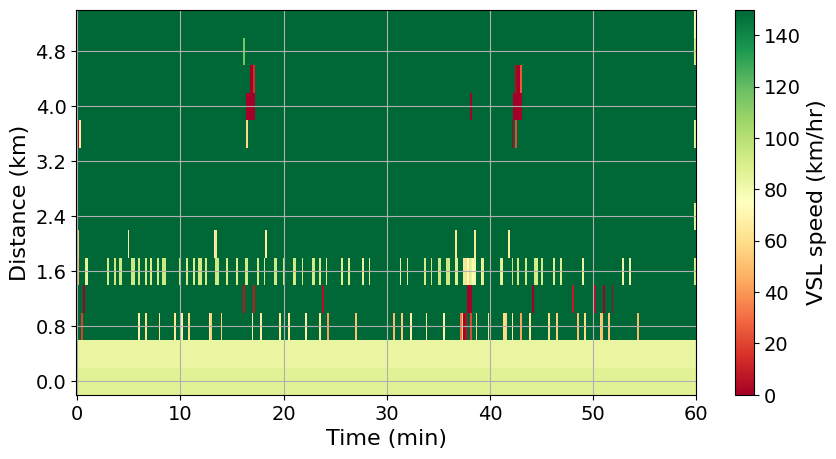

In [45]:
from plotting import plot_vsls
# optimal_vsl = np.load(f'{results_path}/optimal_vsl_90.npy')
v_free_extended = np.tile(model_params['v_free'], (optimal_vsl.shape[0], 1))
optimal_vsl = np.where(optimal_vsl > v_free_extended, 150, optimal_vsl)
plot_vsls(optimal_vsl, time_steps+1, num_segments, np.max(model_params['v_free']), T=time_step, l=L)

In [465]:
# Extend v_free array to match time steps
v_free_extended = np.tile(i24params['v_free'], (optimal_vsl.shape[0], 1))
print(v_free_extended.shape)

NameError: name 'i24params' is not defined

In [466]:
plot_vsls(v_free_extended, opt_time+1, num_segments, max(i24params['v_free']), T=time_step, l=L)

NameError: name 'opt_time' is not defined

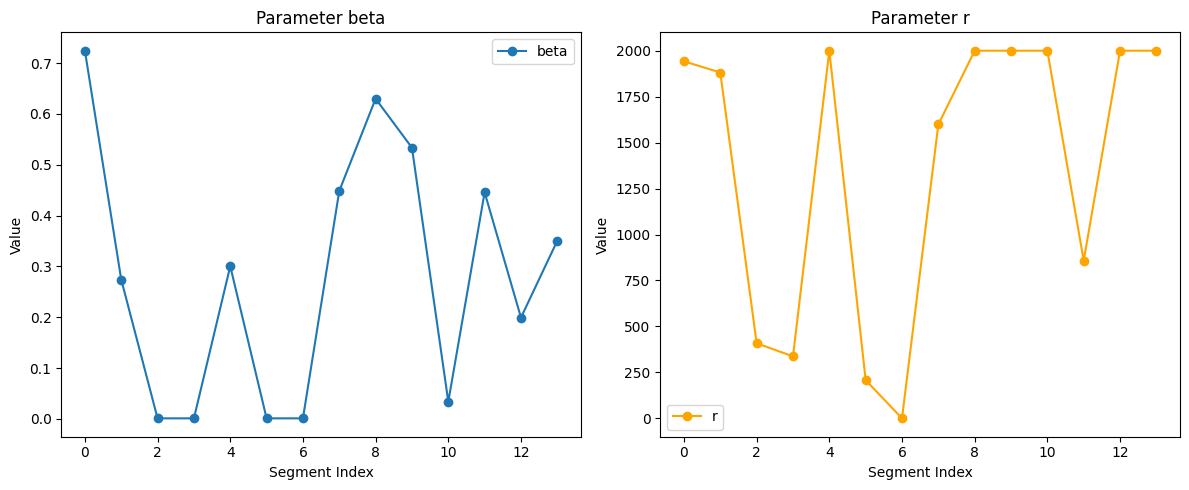

In [145]:
# Plot beta and r
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].plot(i24params['beta'], marker='o', label='beta')
axs[0].set_xlabel('Segment Index')
axs[0].set_ylabel('Value')
axs[0].set_title('Parameter beta')
axs[0].legend()
axs[1].plot(i24params['r'], marker='o', label='r', color='orange')
axs[1].set_xlabel('Segment Index')
axs[1].set_ylabel('Value')
axs[1].set_title('Parameter r')
axs[1].legend()
plt.tight_layout()
plt.show()

In [146]:
print(np.max(data_inflow)/sim_lanes[0])
print(np.max(gt_density/lane_counts))

1583.0001000000061
56.267499062500065


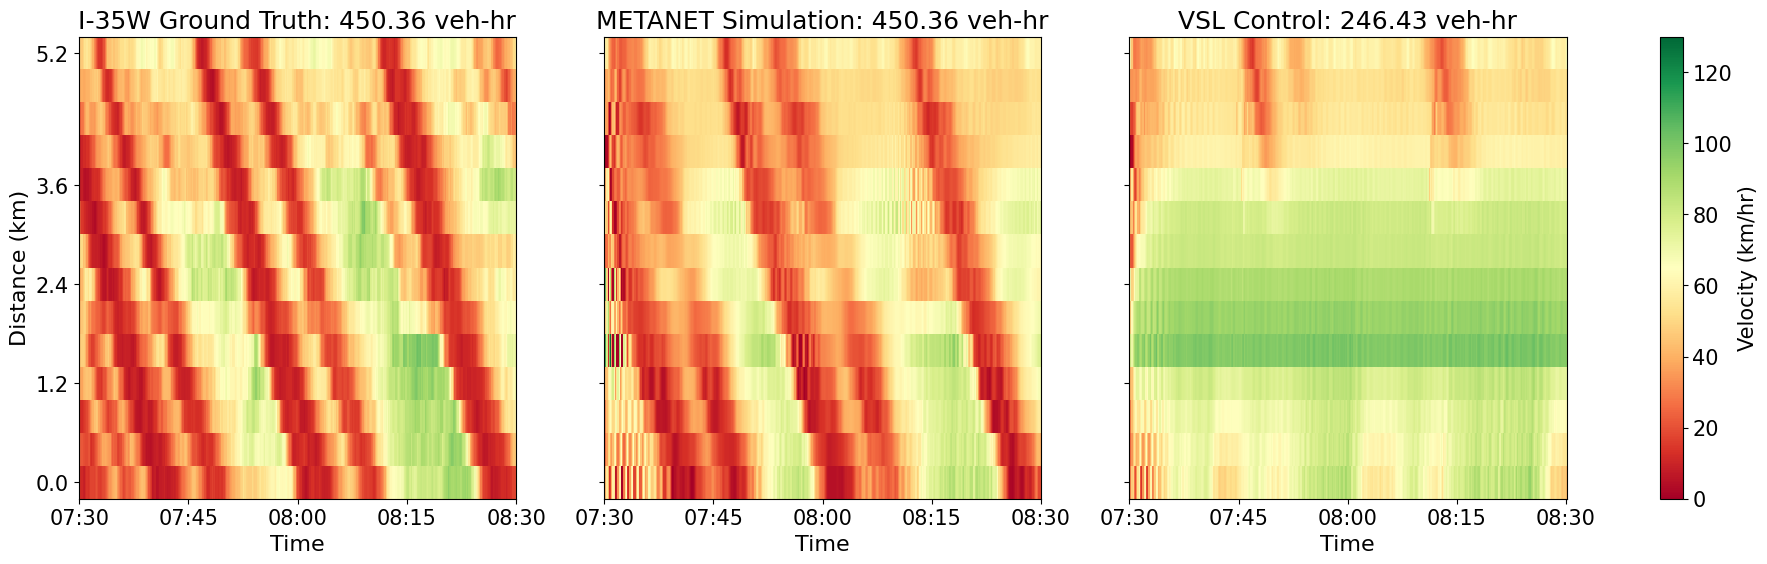

In [319]:
start_wallclock_time = 7.5
plt.rcParams.update({'font.size': 20, 
                    #  "font.family": "serif",
                    "font.serif": ["Helvetica Neue"]})  # Use Computer Modern for text})

fig, axs = plt.subplots(1, 3, figsize=(24, 6), sharey=True)
# start_wallclock_time = 7

n_time = velocity_data[:, 1:-1].shape[0] +1
minutes = np.arange(n_time) * time_step * 60
tick_pos = np.linspace(0, n_time - 1, 5, dtype=int)

def to_wallclock(tick_minutes, start_hour):
    labels = []
    for m in tick_minutes:
        total_minutes = start_hour * 60 + m
        h = int(total_minutes // 60) % 24
        mn = int(total_minutes % 60)
        labels.append(f"{h:02d}:{mn:02d}")
    return labels

tick_labels = to_wallclock(minutes[tick_pos], start_wallclock_time)

# Compute y ticks in km — add this before the imshow calls
n_segments = velocity_data[:, 1:-1].shape[1]
ytick_pos = np.linspace(0, n_segments - 1, 5, dtype=int)
ytick_labels = [f"{i * 0.4:.1f}" for i in ytick_pos]  # 400m per segment → km

# Plot ground truth (I-35W)
im0 = axs[0].imshow(velocity_data[:, 1:-1].T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=0, vmax=130)
axs[0].set_title('I-35W Ground Truth: ' + str(np.round(tts_baseline, 2)) + ' veh-hr', fontsize=18)
axs[0].set_xlabel('Time', fontsize=16)
axs[0].set_ylabel('Distance (km)', fontsize=16)
axs[0].invert_yaxis()
axs[0].xaxis.set_ticks_position('bottom')
axs[0].set_xticks(tick_pos)
axs[0].set_xticklabels(tick_labels, fontsize=15)
axs[0].set_yticks(ytick_pos)
axs[0].set_yticklabels(ytick_labels, fontsize=15)

# Plot METANET ground truth
im1 = axs[1].imshow(v_baseline.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=0, vmax=130)
axs[1].set_title('METANET Simulation: ' + str(np.round(tts_baseline, 2)) + ' veh-hr', fontsize=18)
axs[1].set_xlabel('Time', fontsize=16)
axs[1].invert_yaxis()
axs[1].xaxis.set_ticks_position('bottom')
axs[1].set_xticks(tick_pos)
axs[1].set_xticklabels(tick_labels, fontsize=15)

# Plot METANET with control
im2 = axs[2].imshow(v_opt.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=0, vmax=130)
axs[2].set_title('VSL Control: ' + str(np.round(tts_opt, 2)) + ' veh-hr', fontsize=18)
axs[2].set_xlabel('Time', fontsize=16)
axs[2].invert_yaxis()
axs[2].xaxis.set_ticks_position('bottom')
axs[2].set_xticks(tick_pos)
axs[2].set_xticklabels(tick_labels, fontsize=15)

# Single shared colorbar on the right
cbar = fig.colorbar(im2, ax=axs, label='Velocity (km/hr)', shrink=1)
cbar.ax.tick_params(labelsize=15)
cbar.set_label('Velocity (km/hr)', fontsize=15)

# plt.tight_layout()
plt.show()

In [341]:
from generate_demand import get_ff_tts

ff_ttt = get_ff_tts(data_inflow, time_step, L, i24params['v_free'])
print(ff_ttt)
delay  = tts - ff_ttt
opt_delay = tts_opt - ff_ttt
cc = (delay - opt_delay) / delay * 100
print(f"Controllable congestion: {cc}%")


371.2814773023062
Controllable congestion: 84.46778106197337%


In [321]:
print(i24params['r'])
print(i24params['beta'])

[1942.45330296 1881.26414306  408.44052352  337.1344656  1999.99999923
  207.89236884    0.0010001  1598.89684406 1999.99999949 1999.99999981
 1999.9999998   857.75376696 1999.99999979 1999.99999716]
[0.72417084 0.27385375 0.001      0.001      0.30026505 0.001
 0.001      0.44838782 0.62973093 0.53334154 0.03376783 0.44548328
 0.19922066 0.35040321]


In [342]:
ccs = []
ff_ttt = get_ff_tts(data_inflow, time_step, L, i24params['v_free'])
speeds = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 125, 150]
segs=[2, 3, 4, 5, 6, 7, 15, 16, 17, 18]
seg=False

for speed in speeds:
    if speed == 100 or speed == 125:
        ccs.append(0)  # Placeholder for missing data
    else:
        opt_vsl = np.load(f"src/sim_params/{exp_path}/optimal_vsl_speedlb{speed}.npy")
        p, v_opt, queue, tts_opt = run_metanet_sim(time_step,
                                    L, 
                                    init_state, 
                                        data_inflow[start_time:start_time+opt_time],
                                        downstream_density[start_time:start_time+opt_time],
                                        i24params,
                                        vsl_speeds=opt_vsl,
                                        lanes = sim_lanes,
                                        plotting=True,
                                        real_data=False)
        
        delay  = tts - ff_ttt
        opt_delay = tts_opt - ff_ttt
        cc = (delay - opt_delay) / delay * 100
        ccs.append(cc)

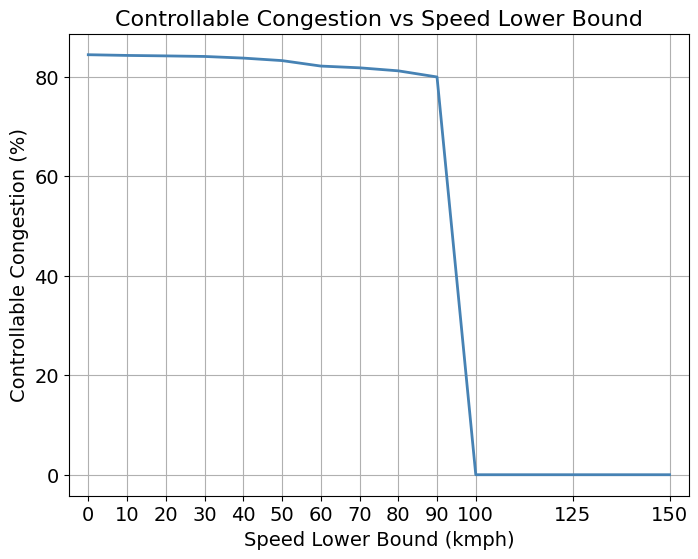

In [346]:
# Plot ccs in a scatter plot
# I want time
if seg:
    plt.figure(figsize=(8, 6))
    plt.plot(segs, ccs, marker = 'o', color='steelblue')
    plt.xlabel('Speed Lower Bound (mph)', fontsize=14)
    plt.ylabel('Controllable Congestion (%)', fontsize=14)
    plt.title('Controllable Congestion vs Speed Lower Bound', fontsize=16)
    # plt.xticks(np.array(speeds), fontsize=14)
    plt.yticks(fontsize=14)
    # plt.xlim([min(speeds)*0.63 - 5, max(speeds)*0.63 + 5])
    plt.grid()
    plt.show()
else:
    plt.figure(figsize=(8, 6))
    plt.plot(np.array(speeds), ccs, color='steelblue', linewidth=2)
    plt.xlabel('Speed Lower Bound (kmph)', fontsize=14)
    plt.ylabel('Controllable Congestion (%)', fontsize=14)
    plt.title('Controllable Congestion vs Speed Lower Bound', fontsize=16)
    plt.xticks(np.array(speeds), fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlim([min(speeds) - 5, max(speeds) + 5])
    plt.grid()
    plt.show()

In [322]:
# pointwise delay
# --- Compute Delay ---
# free_flow_speed shape: (n_segments,) → reshape to (n_segments, 1) to broadcast over time
free_flow_speed_2d = np.array(i24params['v_free'])[:, np.newaxis]  # or .reshape(-1, 1)

delay_gt   = (0.4 / velocity_data[:, 1:-1].T - 0.4 / free_flow_speed_2d) * 60
delay_ctrl = (0.4 / v_opt[0:-1, :].T - 0.4 / free_flow_speed_2d) * 60

print(np.min(delay_gt), np.max(delay_gt))

print(delay_gt.shape, delay_ctrl.shape)

with np.errstate(divide='ignore', invalid='ignore'):
    pct_decrease = np.where(
        delay_gt > 0.01,
        (delay_gt - delay_ctrl) / delay_gt * 100,
        0
    )

print(np.max(pct_decrease), np.min(pct_decrease))

-0.05382089932793031 7.425882196986553
(14, 360) (14, 360)
525.2420653787359 -883416.0518150718


In [323]:
# ground truth total time spent
num_lanes_array = np.array([sim_lanes[i] for i in range(num_segments)])

tts_raw = np.sum(density_data[:, 1:-1]/num_lanes_array * time_step)
print(time_step)
print(f"Raw TTS from data: {tts_raw} veh-hr")

0.002777777777777778
Raw TTS from data: 351.3448781905381 veh-hr


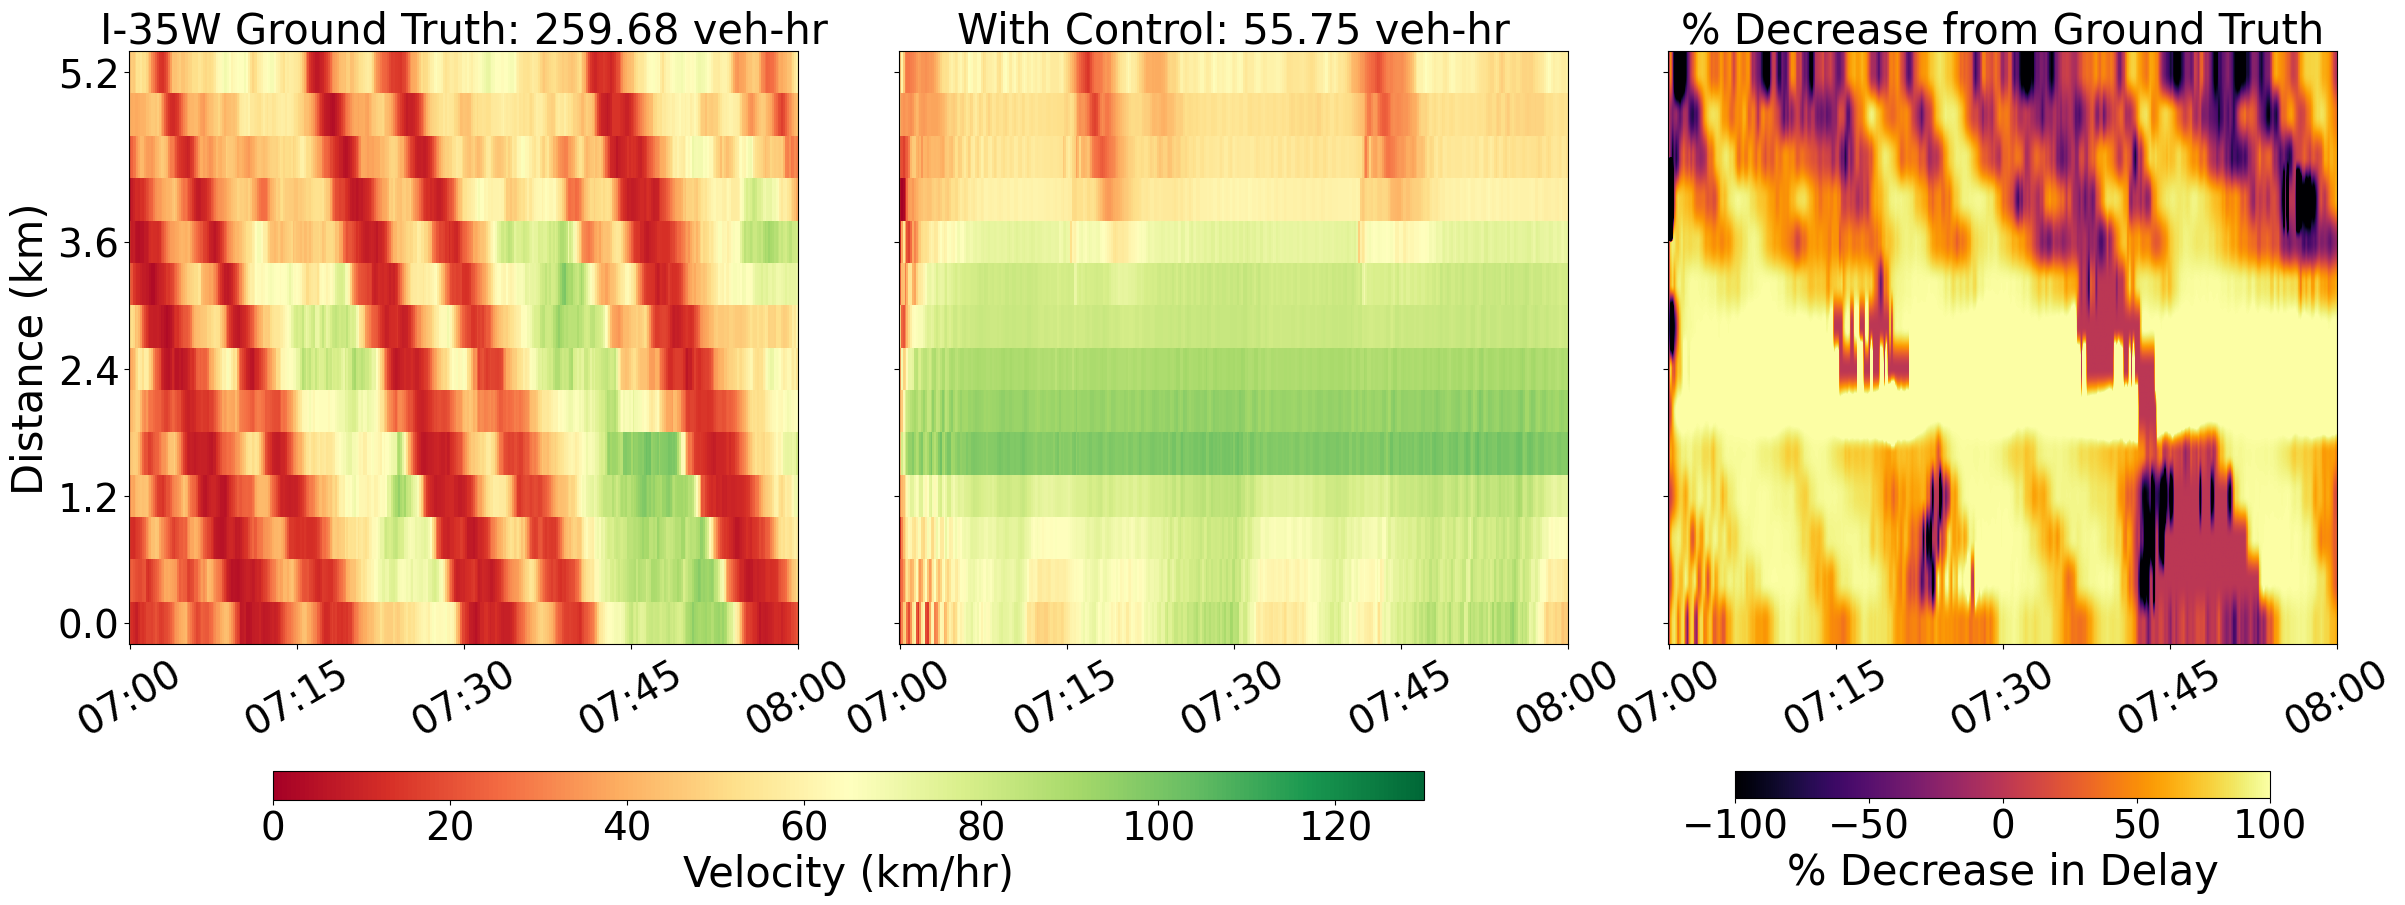

In [324]:
plt.rcParams.update({
    'font.size':        18,   # default for all text
    'axes.titlesize':   30,   # subplot titles
    'axes.labelsize':   30,   # x and y axis labels
    'xtick.labelsize':  28,   # x tick labels
    'ytick.labelsize':  28,   # y tick labels
    'legend.fontsize':  25,   # legend
    'figure.titlesize': 20,   # suptitle
    "font.family": "sans-serif",
    "font.serif": ["Helvetica Neue"]  # Use Helvetica Neue for text
})

fig = plt.figure(figsize=(24, 11))

from matplotlib.gridspec import GridSpec
gs = GridSpec(1, 3, figure=fig, left=0.05, right=0.97, wspace=0.15)

axs = [fig.add_subplot(gs[0, i]) for i in range(3)]

for ax in axs[1:]:
    ax.sharey(axs[0])

pos1 = axs[1].get_position()
pos2 = axs[2].get_position()
gap = 0.02
axs[2].set_position([pos1.x1 + gap, pos2.y0, pos2.width, pos2.height])

n_time = v_opt.shape[0]
minutes = np.arange(n_time) * time_step * 60
tick_pos = np.linspace(0, n_time - 1, 5, dtype=int)

def to_wallclock(tick_minutes, start_hour):
    labels = []
    for m in tick_minutes:
        total_minutes = start_hour * 60 + m
        h = int(total_minutes // 60) % 24
        mn = int(total_minutes % 60)
        labels.append(f"{h:02d}:{mn:02d}")
    return labels

tick_labels = to_wallclock(minutes[tick_pos], 7)

n_segments = v_opt.shape[1]
ytick_pos = np.linspace(0, n_segments-1, 5, dtype=int)
ytick_labels = [f"{i * 0.4:.1f}" for i in ytick_pos]

# --- Plot 1: Ground Truth ---
im0 = axs[0].imshow(velocity_data[:, 1:-1].T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=0, vmax=130)
axs[0].set_title('I-35W Ground Truth: ' + str(np.round(delay, 2)) + ' veh-hr')
# axs[0].set_xlabel('Time')
axs[0].set_ylabel('Distance (km)')
axs[0].invert_yaxis()
axs[0].xaxis.set_ticks_position('bottom')
axs[0].set_xticks(tick_pos)
axs[0].set_xticklabels(tick_labels)
axs[0].set_yticks(ytick_pos)
axs[0].set_yticklabels(ytick_labels)

# --- Plot 2: VSL Control ---
im1 = axs[1].imshow(v_opt[0:-1, :].T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=0, vmax=130)
axs[1].set_title('With Control: ' + str(np.round(opt_delay, 2)) + ' veh-hr')
# axs[1].set_xlabel('Time')
axs[1].invert_yaxis()
axs[1].xaxis.set_ticks_position('bottom')
axs[1].set_xticks(tick_pos)
axs[1].set_xticklabels(tick_labels)
axs[1].tick_params(labelleft=False)

# Shared horizontal colorbar below plots 1 & 2
cbar0 = fig.colorbar(im1, ax=axs[:2], orientation='horizontal', location='bottom',
                      pad=0.15, shrink=0.8, aspect=40)
cbar0.set_label('Velocity (km/hr)')

# --- Plot 3: % Decrease in Delay ---
im2 = axs[2].imshow(pct_decrease, cmap='inferno', aspect='auto', vmin=-100, vmax=100)
axs[2].set_title('% Decrease from Ground Truth')
# axs[2].set_xlabel('Time')
axs[2].invert_yaxis()
axs[2].xaxis.set_ticks_position('bottom')
axs[2].set_xticks(tick_pos)
axs[2].set_xticklabels(tick_labels)
axs[2].tick_params(labelleft=False)

# Horizontal colorbar below plot 3
cbar1 = fig.colorbar(im2, ax=axs[2], orientation='horizontal', location='bottom',
                      pad=0.15, shrink=0.8, aspect=20)
cbar1.set_label('% Decrease in Delay')

for ax in axs:
    ax.tick_params(axis='x', labelrotation=30)

plt.show()

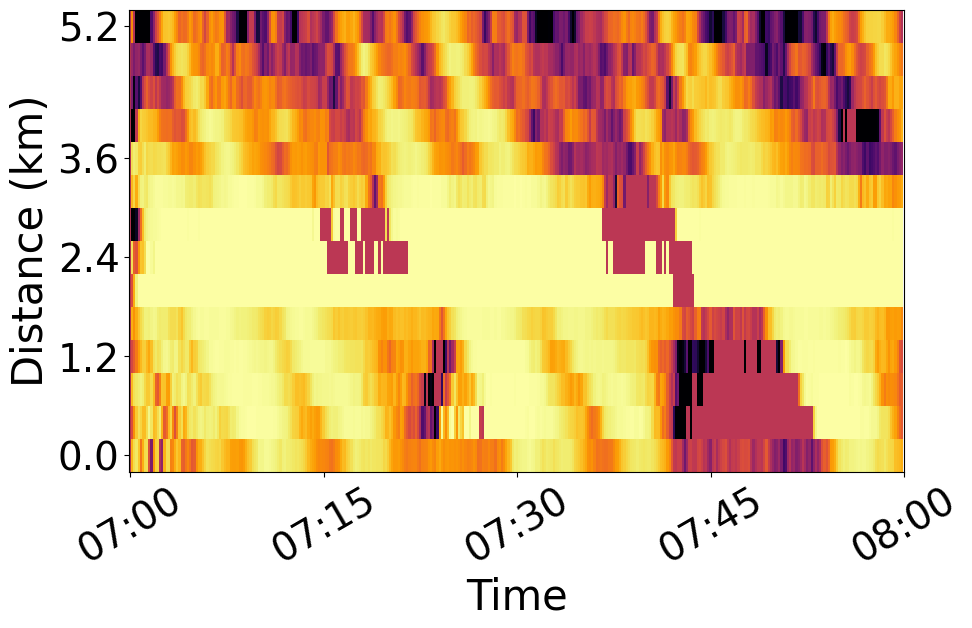

In [325]:
# Plot just the percent decrease in delay
plt.figure(figsize=(10, 6))
im = plt.imshow(pct_decrease, cmap='inferno', aspect='auto', vmin=-100, vmax=100, interpolation='none')
# plt.title('% Decrease in Delay from Ground Truth')
plt.xlabel('Time')
plt.ylabel('Distance (km)')
plt.gca().invert_yaxis()
plt.gca().xaxis.set_ticks_position('bottom')
plt.xticks(tick_pos, tick_labels, rotation=30)
# cbar = plt.colorbar(im, label='% Decrease in Delay')

plt.gca().set_xticks(tick_pos)
plt.gca().set_xticklabels(tick_labels)
plt.gca().set_yticks(ytick_pos)
plt.gca().set_yticklabels(ytick_labels)
plt.show()